In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pybaselines import Baseline, utils
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
import os 
import glob
from galvani import BioLogic as BL

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio # For Plotly themes 
from datetime import datetime, timedelta

C:\Users\b1104371\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Function for reading files

In [3]:
def read_data(file_name):
    legend_temp = []
    data_line_temp = []
    time_stamp_temp = []
    data_storing = False
    print(f"Reading file: {file_name}")
    with open(file_name, 'r') as file:
        for line in file:
            if 'q(A-1)' in line:
                data_storing = True
                continue
            if 'Comment' in line:
                legend_temp = line.split()[4]
            if 'Date' in line:
                time_stamp_temp = line.split()[2] 
            if data_storing:
                data_line_temp.append(line.strip())
    df_temp= pd.DataFrame([line.split() for line in data_line_temp])
    df_temp= df_temp.astype(float)

    return legend_temp, time_stamp_temp ,df_temp

    

# Function for finding timestamps

In [4]:
def find_nearest_time(target_time, discharge_start_time, total_cycle_time, time_dict):
    new_time_dict = {}

    base_time = datetime.strptime(time_dict[1], '%Y-%m-%dT%H:%M:%S')

    for key in time_dict:
        current_time = datetime.strptime(time_dict[key], '%Y-%m-%dT%H:%M:%S')
        time_difference = (current_time - base_time).total_seconds()
        new_time_dict[time_difference] = key
#     print(new_time_dict)
    nearest_time_difference = min(new_time_dict, key=lambda x: abs(x - target_time))
    nearest_key = new_time_dict[nearest_time_difference]
    
    discharge_time_difference = min(new_time_dict, key=lambda x: abs(x - (target_time+discharge_start_time)))
    discharge_key = new_time_dict[discharge_time_difference]
    
    furthest_time_difference = min(new_time_dict, key=lambda x: abs(x - (target_time+total_cycle_time)))
    furthest_key = new_time_dict[furthest_time_difference]
    
    return nearest_key, discharge_key, furthest_key, new_time_dict

# Fitting Functions

In [155]:
def lorentzian(x, a, x0, w0):
    return a* w0**2 / (w0**2 + (x - x0)**2)

def multi_lorentzian(x, *params):
    # mean_positions = [18.6, 19.13, 19.5, 19.9, 20.8]
    # mean_positions = [18.6, 19.13, 19.9, 20.8]
    mean_positions = [16.63, 18.55, 19.4]
    # mean_positions = [19,19.8]
    baseline = params[-1]
    y = np.zeros_like(x) + baseline
    for j in range(len(mean_positions)):
        x0 = mean_positions[j]
        a  = params[2*j]
        w0 = params[2*j+1]
        y += lorentzian(x, a, x0, w0)
    return y

In [6]:
def smooth_data(data, window_length=10, polyorder=3):
    return savgol_filter(data, window_length, polyorder)

# Read all the files

In [7]:
os.chdir(r'E:\SAXS_WAXS\data\Test_data\20240604_2503-SKJB_6MECDEC_100volHFE')
mpr = BL.MPRfile('./2503-SKJB-1pt07mg_6MECDEC_100volHFE-1_C02.mpr')
#os.chdir(r'C:\Users\b1104371\OneDrive - Universität Salzburg\Research\Electrolyte variation\Charecterizations\SAXS\After_Beamtime\1705-SSup\20240624_1705-SSup_ECDEC_100HFE\cycling')
#mpr = BL.MPRfile('./1705_SSuP_1pt14mg_6M_ECDEC_100vol_HFE_C02.mpr')

file_list = glob.glob('*_1_*.dat')

legend = {} #Dictionary for storing the comments from experiment data files to be used as legends later
time_stamp = {} #Dictionary to store the time of file creation
key = 0
file_dictionary = {} # Dictionary for storing all the pandas data file 

# Read all the files data from the directory and also the comments and file generation time in seperate pd dataframe

for data_file in file_list:
    key += 1
    legend[key], time_stamp[key], file_dictionary[key] = read_data(data_file)

    
print('Number of files:',key)

Reading file: 6MECDEC_100volHFE_1_00001.dat
Reading file: 6MECDEC_100volHFE_1_00002.dat
Reading file: 6MECDEC_100volHFE_1_00003.dat
Reading file: 6MECDEC_100volHFE_1_00004.dat
Reading file: 6MECDEC_100volHFE_1_00005.dat
Reading file: 6MECDEC_100volHFE_1_00006.dat
Reading file: 6MECDEC_100volHFE_1_00007.dat
Reading file: 6MECDEC_100volHFE_1_00008.dat
Reading file: 6MECDEC_100volHFE_1_00009.dat
Reading file: 6MECDEC_100volHFE_1_00010.dat
Reading file: 6MECDEC_100volHFE_1_00011.dat
Reading file: 6MECDEC_100volHFE_1_00012.dat
Reading file: 6MECDEC_100volHFE_1_00013.dat
Reading file: 6MECDEC_100volHFE_1_00014.dat
Reading file: 6MECDEC_100volHFE_1_00015.dat
Reading file: 6MECDEC_100volHFE_1_00016.dat
Reading file: 6MECDEC_100volHFE_1_00017.dat
Reading file: 6MECDEC_100volHFE_1_00018.dat
Reading file: 6MECDEC_100volHFE_1_00019.dat
Reading file: 6MECDEC_100volHFE_1_00020.dat
Reading file: 6MECDEC_100volHFE_1_00021.dat
Reading file: 6MECDEC_100volHFE_1_00022.dat
Reading file: 6MECDEC_100volHFE_

In [5]:
pio.templates.default = "simple_white"
fig = go.Figure()
for key in file_dictionary:
    X_data = file_dictionary[key].iloc[:,0]
    Y_data = file_dictionary[key].iloc[:,1]
    fig.add_trace(go.Scatter(x = X_data, y = Y_data))

fig.show()

NameError: name 'file_dictionary' is not defined

# Read EC lab files 

Indices for cycle change: [0, 4402, 6478, 8651, 10492, 12416, 14293]


Text(0, 0.5, 'Potential (V)')

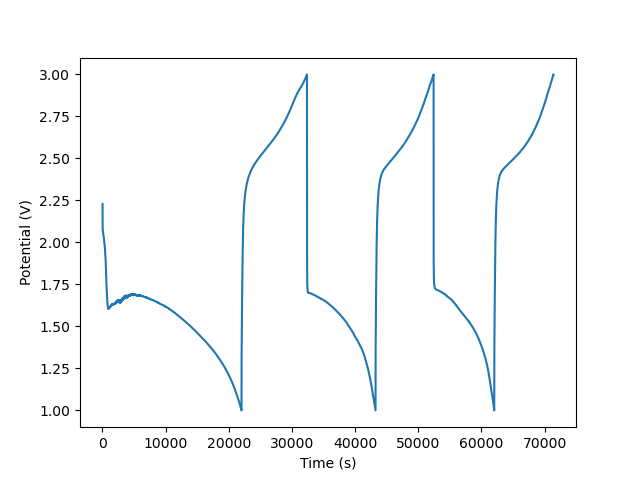

In [8]:
#mpr = BL.MPRfile('./2503-SKJB-1pt07mg_6MECDEC_100volHFE-1_C02.mpr')

elec_df_temp = pd.DataFrame(mpr.data)
#print(elec_df_temp)

    # Filter the data for the OCV from the dataframe 
filter = elec_df_temp['Ns'] != 0
elec_df = elec_df_temp[filter]
elec_df.to_csv('electrochem_datafile.txt', sep = '\t')

    # Track the diffent times for charge-discharge by noting when the Ns value changes

cycle_change_index = []
cycle_change_index.append(0)
for index in range(len(elec_df['Ns'])-1):
    if elec_df['Ns'].iloc[index] != elec_df['Ns'].iloc[index+1]:
        cycle_change_index.append(index)
cycle_change_index.append(index+1) #Takes the index for the last file also  
print("Indices for cycle change:", cycle_change_index)

    # Plot the read electrochemical file
Elec_Xdata = elec_df['time/s']
Elec_Ydata = elec_df['Ewe/V']
plt.figure()
plt.plot(Elec_Xdata,Elec_Ydata)
plt.xlabel('Time (s)')
plt.ylabel('Potential (V)')

# Data Segregation

In [9]:
print('Total number of cycles:', len(cycle_change_index)//2)

# Filter the DataFrame by the condition
starting_cycle = int(input("Starting cycle to plot:"))
end_cycle = int(input("Final cycle to plot:"))

# Initial and final line numbers for the chosen cycle to plot:
initial_line = cycle_change_index[2*starting_cycle-2]
change_cycle_line = cycle_change_index[2*starting_cycle-1]
final_line = cycle_change_index[2*end_cycle]
print('\nBiologic data file line details:')
print('initial_line,change_cycle_line, final_line:',initial_line,change_cycle_line, final_line)

elec_df_2 = elec_df.iloc[initial_line:final_line]
elec_df_2.to_csv('electrochem_datafile2.txt', sep = '\t')

time_when_change = elec_df.iloc[change_cycle_line].loc['time/s']
print("\ntime when cycle change:",time_when_change)

# Reference times to segregate SAXS data files
ref_time = int(elec_df_2['time/s'].iloc[0] - elec_df['time/s'].iloc[0])
total_cycle_time = int(elec_df_2['time/s'].iloc[-1] - int(elec_df_2['time/s'].iloc[0]))
discharge_start_time = int(time_when_change - elec_df_2['time/s'].iloc[0])
print()
print(f'Ref. time, relative discharge start and Total cycle time:{ref_time}s, {discharge_start_time} and {total_cycle_time}s\n')

# find the corresponding starting abd ending SAXS file
starting_file, discharge_file, last_file, new_time_dict  = find_nearest_time(ref_time, discharge_start_time, total_cycle_time, time_stamp)

print(f"Starting SAXS file no.: {starting_file}")
print(f"Discharge SAXS file no.: {discharge_file}")
print(f"Last SAXS file no.: {last_file}\n")
print('Time stamps:')
print('Initial file:',time_stamp[starting_file], "Discharge file:",time_stamp[discharge_file],'Last file:', time_stamp[last_file])

Total number of cycles: 3

Biologic data file line details:
initial_line,change_cycle_line, final_line: 0 4402 14293

time when cycle change: 22013.509079595562

Ref. time, relative discharge start and Total cycle time:0s, 22003 and 71394s

Starting SAXS file no.: 1
Discharge SAXS file no.: 109
Last SAXS file no.: 354

Time stamps:
Initial file: 2024-06-03T15:03:50 Discharge file: 2024-06-03T21:09:51 Last file: 2024-06-04T10:54:10


# For Baseline correction (manually select the first long exposure file)

Reading file: beckground_with_Al_WAXS.dat
filtered position: 45, 608, value: 9.981359083639482, 24.98671332686787


"plt.xlabel('q (nm $^{-1}$)')\nplt.ylabel('Intensity (a.u.)')\nplt.xlim(15,22)\nplt.ylim(-0.001,0.008)"

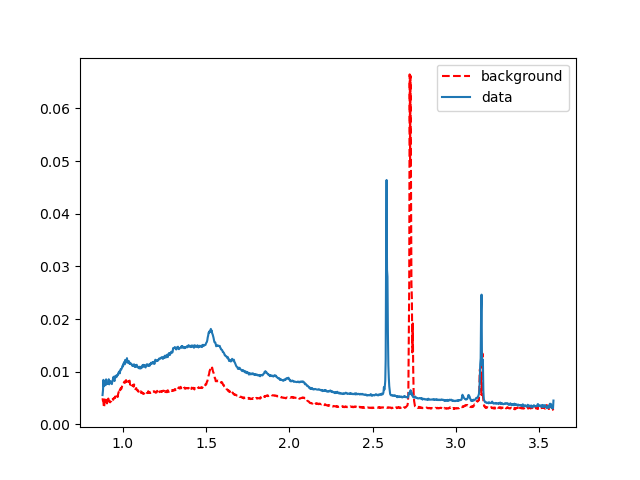

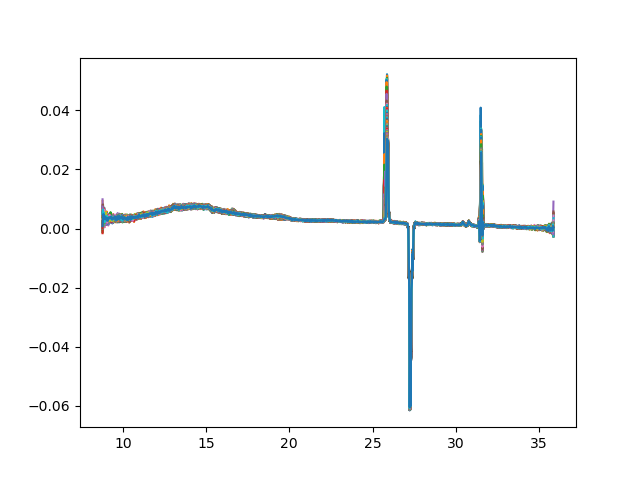

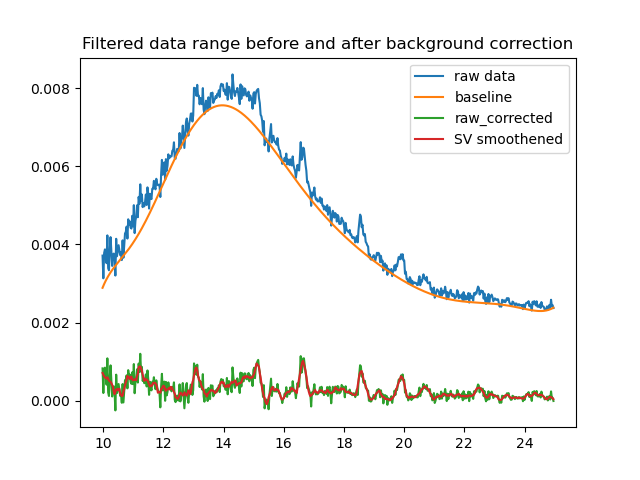

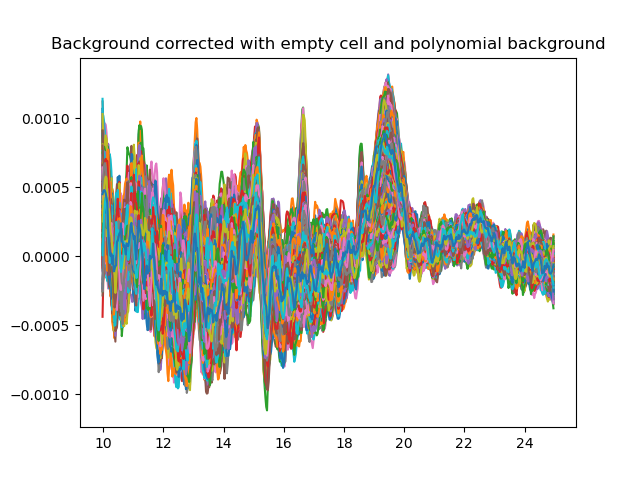

In [86]:
plt.figure()
background_file = glob.glob('*_Al_WAXS.dat')

for input in background_file:
    a1,a2,background = read_data(input)
# print(background.iloc[:,0])
plt.plot(background.iloc[:,0], 1*background.iloc[:,1], 'r--', label = 'background')
plt.plot(file_dictionary[1].iloc[:,0],file_dictionary[1].iloc[:,1], label = 'data')
plt.legend()
plt.figure()

empty_cell_corrected_waxs_files = {}

for ikey in file_dictionary:
    X_data = 10*file_dictionary[ikey].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary[ikey].iloc[:,1]
    modified_Y = Y_data - 1* background.iloc[:,1]
    plt.plot(X_data, modified_Y)
    df = pd.DataFrame({'X_data': X_data, 'Modified_Y': modified_Y})
    empty_cell_corrected_waxs_files[ikey] = df

#filter the range for the WAXS
filtered_X_range_min = np.max(np.where(X_data <= 10))
filtered_X_range_max = np.max(np.where(X_data <= 25))
# print(empty_cell_corrected_waxs_files)
print(f"filtered position: {filtered_X_range_min}, {filtered_X_range_max}, value: {X_data[filtered_X_range_min]}, {X_data[filtered_X_range_max]}")

                                  # Substract a polynomial over the empty cell corrected files #


# Create an average over the first four files for background generation
x_data = 0
y_data = 0
file_count = 0
for files in range(1,5):
    x_data += empty_cell_corrected_waxs_files[files].iloc[filtered_X_range_min:filtered_X_range_max,0]
    y_data += empty_cell_corrected_waxs_files[files].iloc[filtered_X_range_min:filtered_X_range_max,1]
    file_count += 1

# average over the summed data 
x_data = x_data/file_count
y_data = y_data/file_count

plt.figure()
plt.title("Filtered data range before and after background correction")
baseline_filter = Baseline(x_data = x_data)
baseline = baseline_filter.modpoly(y_data, poly_order= 10)[0]
# print(baseline)
modified_y = y_data-baseline
smoothed_Y = smooth_data(modified_y, window_length=11, polyorder=2)

plt.plot(x_data, y_data, label = 'raw data')
plt.plot(x_data, baseline, label = 'baseline')
plt.plot(x_data, modified_y, label = 'raw_corrected')
plt.plot(x_data, smoothed_Y, label = 'SV smoothened')
plt.legend()

plt.figure()
plt.title("Background corrected with empty cell and polynomial background")
# Create new file dictionary with corrected spectra
corrected_waxs_files = {}

for ikey in empty_cell_corrected_waxs_files:
    min_val = 0
    max_val = 0
    modified_Y = 0
    X1_values = empty_cell_corrected_waxs_files[ikey].iloc[filtered_X_range_min:filtered_X_range_max,0] 
    Y1_values = empty_cell_corrected_waxs_files[ikey].iloc[filtered_X_range_min:filtered_X_range_max,1]
    modified_Y = Y1_values - baseline

    # Smooth the data
    smoothed_Y = smooth_data(modified_Y, window_length=11, polyorder=2)

    # min_val = np.min(smoothed_Y)
    # max_val = np.max(smoothed_Y)
    normalized_Y = smoothed_Y #'(smoothed_Y - min_val)/(max_val - min_val)' # Normalized the data between [0,1]
    plt.plot(X1_values, normalized_Y)
    df = pd.DataFrame({'X_data': X1_values, 'Modified_Y': normalized_Y})
    corrected_waxs_files[ikey] = df

#Setting graph attributes
# plt.ylim(-0.1,1.2)
"""plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.xlim(15,22)
plt.ylim(-0.001,0.008)"""

# Creating the Polynomial background (With a average over the first three files)

'plt.xlim(15,22)\nplt.ylim(-0.001,0.008)'

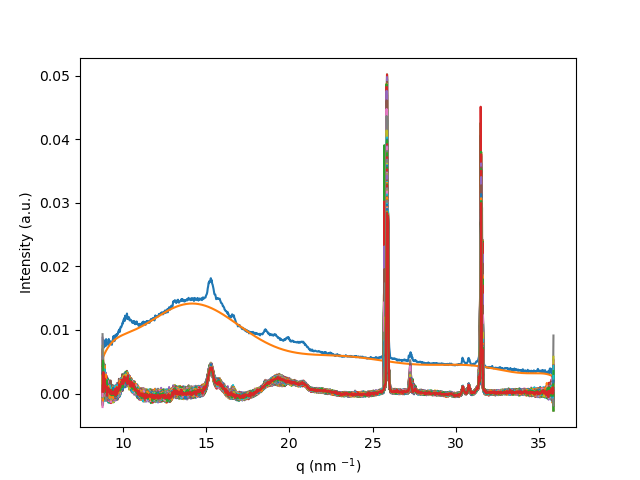

In [62]:
X_data = []
Y_data = []

# Create a average over the first three data files 
plt.figure()
for files in range(1,4):
    if files == 1:
        X_data = 10*file_dictionary[files].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
        Y_data = file_dictionary[files].iloc[:,1]
        # print(X_data)
    else:
        X_data += 10*file_dictionary[files].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
        Y_data += file_dictionary[files].iloc[:,1]

for entries in range(len(X_data)):
    X_data[entries] = X_data[entries]/3
    Y_data[entries] = Y_data[entries]/3

baseline_filter = Baseline(x_data = X_data)
baseline = baseline_filter.modpoly(Y_data, poly_order= 10)[0]
# print(baseline)
modified_Y = Y_data-baseline
plt.plot(X_data, Y_data)
plt.plot(X_data, baseline)
plt.plot(X_data, modified_Y)

# Create new file dictionary with corrected spectra
corrected_waxs_files = {}
for ikey in file_dictionary:
    X_data = 10*file_dictionary[ikey].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary[ikey].iloc[:,1]
    modified_Y = Y_data - baseline
    plt.plot(X_data, modified_Y)
    df = pd.DataFrame({'X_data': X_data, 'Modified_Y': modified_Y})
    corrected_waxs_files[ikey] = df

#Setting graph attributes
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')
"""plt.xlim(15,22)
plt.ylim(-0.001,0.008)"""

# Check the plot for determination of two-theta and no of peaks for fitting 

[0, 0, 0, 0, 0, 0, -0.0002017084806186319]
Peak 1:
 Amplitude = 0.0005 +/- 0.0001
 Center = 16.60
 Width = 0.0881 +/- 0.0189
Peak 2:
 Amplitude = 0.0002 +/- 0.0189
 Center = 18.55
 Width = 1.0000 +/- 0.3058
Peak 3:
 Amplitude = 0.0000 +/- 0.0000
 Center = 19.40
 Width = 0.0000 +/- 0.0000
[ 5.41474765e-04  8.81025541e-02  2.46195111e-04  1.00000000e+00
  1.01943225e-12  1.71677517e-11 -6.45155786e-05]


Text(0, 0.5, 'Intensity (a.u.)')

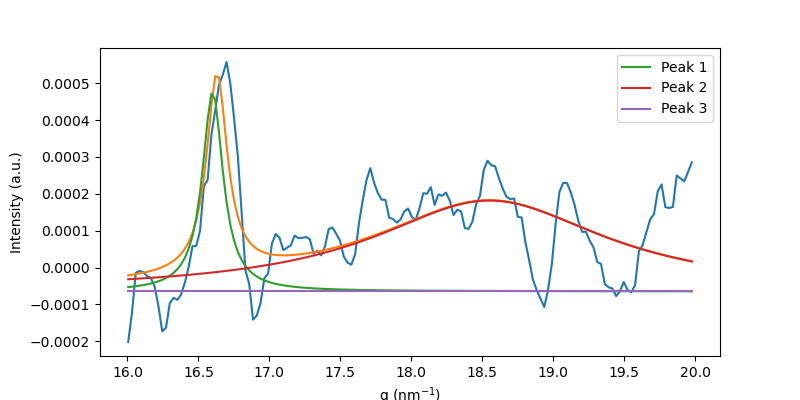

In [198]:
# Filter data between ranges

min_x = 16
max_x = 20

X_positions = corrected_waxs_files[starting_file].iloc[:,0]

indices_within_range = np.where((X_positions >= min_x) & (X_positions <= max_x))

start_row = np.min(indices_within_range)
end_row = np.max(indices_within_range)

# Create new list with the filtered data 

x_filtered = []
y_filtered = [] 

for entry in range(start_row, end_row+1):
    x_temp = corrected_waxs_files[46].iloc[entry,0]
    y_temp = corrected_waxs_files[46].iloc[entry,1]
    x_filtered.append(x_temp)
    y_filtered.append(y_temp)

x_filtered = np.array(x_filtered)
y_filtered = np.array(y_filtered)

# mean_positions = [18.5, 19.1, 19.5, 19.9, 20.8]
# mean_positions = [18.6, 19.13, 19.9, 20.8]
mean_positions = [16.6, 18.55, 19.4]
# mean_positions = [19,19.8]

initial_guess = [0.001, 0.1] * len(mean_positions) + [np.min(y_filtered)]

lower_bounds = [0, 0] * (len(mean_positions)) + [np.min(y_filtered)]
print(lower_bounds)  # Lower and upper bounds for amplitude and width
upper_bounds = [np.inf, 1.0] * (len(mean_positions)) +[2.0]
bounds = (lower_bounds, upper_bounds)

popt_lorentz, pcov_lorentz = curve_fit(multi_lorentzian, xdata= x_filtered, ydata= y_filtered, 
                                       p0 = initial_guess, bounds= bounds, max_nfev=100000)

perr_lorentzian = np.sqrt(np.diag(pcov_lorentz)) # Calculating the errors from the functions


for i in range(len(mean_positions)):
    print(f"Peak {i+1}:")
    print(f" Amplitude = {popt_lorentz[2*i]:.4f} +/- {perr_lorentzian[i]:.4f}")
    print(f" Center = {mean_positions[i]:.2f}")
    print(f" Width = {popt_lorentz[2*i +1]:.4f} +/- {perr_lorentzian[2*i +1]:.4f}")

plt.figure(figsize= (8,4))      
print(popt_lorentz)
plt.plot(x_filtered, y_filtered)
plt.plot(x_filtered, multi_lorentzian(x_filtered, *popt_lorentz))

#for i in range(0, len(popt_lorentz), 3):
#    plt.plot(x_filtered, lorentzian(x_filtered, popt_lorentz[i], popt_lorentz[i+1], popt_lorentz[i+2]), label=f'Peak {i//3 + 1}')

for j in range(len(mean_positions)):
    plt.plot(x_filtered, lorentzian(x_filtered, popt_lorentz[2*j], mean_positions[j], 
                                    popt_lorentz[2*j+1]) + popt_lorentz[-1], label=f'Peak {j + 1}')
    plt.legend()

plt.xlabel("q (nm$^{-1}$)")
plt.ylabel("Intensity (a.u.)")


In [199]:
# Filter data between ranges

X_positions = corrected_waxs_files[starting_file].iloc[:,0]

indices_within_range = np.where((X_positions >= min_x) & (X_positions <= max_x))

start_row = np.min(indices_within_range)
end_row = np.max(indices_within_range)

df_curves = pd.DataFrame() # Dataframe to save the fitted peak area and widths 


# Define bounds for amplitude and width Required to keep amplitudes within positive values

# Create new list with the filtered data 
for file_number in range(starting_file, last_file+1):
    #print(file_number)
    x_filtered = []
    y_filtered = [] 
    lower_bounds = []
    upper_bounds = []

    for entry in range(start_row, end_row+1):
        x_temp = corrected_waxs_files[file_number].iloc[entry,0]
        y_temp = corrected_waxs_files[file_number].iloc[entry,1]
        x_filtered.append(x_temp)
        y_filtered.append(y_temp)

    x_filtered = np.array(x_filtered)
    y_filtered = np.array(y_filtered)
    
    # Define bounds for amplitude and width Required to keep amplitudes within positive values

    initial_guess = [0.0001, 0.1] * len(mean_positions) + [np.min(y_filtered)] # List for initial guesses for peak amplitude, width and baseline
    lower_bounds = [0, 0] * (len(mean_positions)) + [np.min(y_filtered)] # Lower and upper bounds for amplitude and width
    upper_bounds = [np.inf, 1.5] * (len(mean_positions)) + [1.0]
    bounds = (lower_bounds, upper_bounds)

    popt_lorentz, pcov_lorentz = curve_fit(multi_lorentzian, xdata= x_filtered, ydata= y_filtered, p0 = initial_guess, bounds= bounds, max_nfev=10000)

    perr_lorentzian = np.sqrt(np.diag(pcov_lorentz)) # Calculating the errors from the functions
    temp_dict = {}

    for i in range(len(mean_positions)):
        curve_metrics = [] 
        amplitude = popt_lorentz[2*i] - popt_lorentz[-1]
        w0 = popt_lorentz[2*i +1]
        area = np.pi*amplitude*w0
        width = 2*w0
        curve_metrics.append([area,width])
        temp_dict[i+1] = curve_metrics
        temp_df_curve = pd.DataFrame(temp_dict, index= [file_number])

    df_curves = pd.concat([df_curves, temp_df_curve])
print(len(df_curves))

354


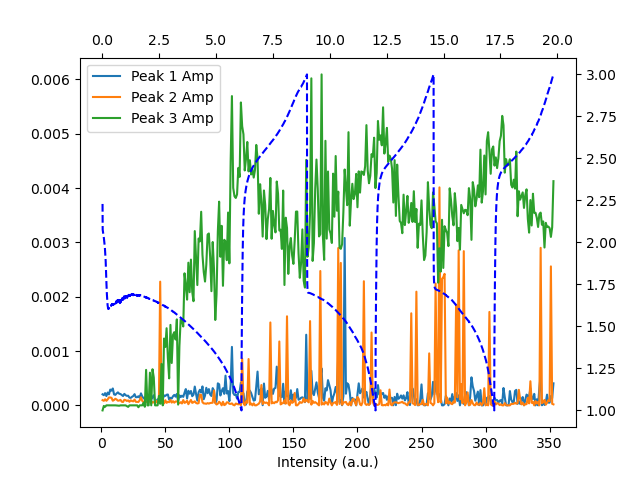

In [201]:
x1, y1, y2, y3, y4, y5 = [[] for _ in range(6)]

for data in range(1,len(df_curves)):
    x1.append(data)
    y1.append(df_curves.loc[data,1][0])
    y2.append(df_curves.loc[data,2][0])
    y3.append(df_curves.loc[data,3][0])
    #y4.append(df_curves.loc[data,4][0])
    #y5.append(df_curves.loc[data,5][0])

"""
plt.figure()
plt.title("Peak areas vs cycle number")
plt.plot(x1,y1, label = 'Peak 1 Amp' )
plt.plot(x1,y2, label = 'Peak 2 Amp')
plt.plot(x1,y3, label = 'Peak 3 Amp')
# plt.plot(x1,y4, label = 'Peak 4 Amp')
# plt.plot(x1,y5, label = 'Peak 5 Amp')
plt.legend()
"""

fig2, ax1 = plt.subplots()
ax1.plot(x1,y1, label = 'Peak 1 Amp' )
ax1.plot(x1,y2, label = 'Peak 2 Amp')
ax1.plot(x1,y3, label = 'Peak 3 Amp')
ax1.set_xlabel('Intensity (a.u.)')
# ax1.plot(x1,y4, label = 'Peak 4 Amp')
# ax1.plot(x1,y5, label = 'Peak 5 Amp')
ax2 = fig2.add_axes(ax1.get_position(), frameon=False)
ax2.plot(Elec_Xdata/3600 ,Elec_Ydata, 'b--')
ax2.xaxis.set_ticks_position('top')
ax2.yaxis.set_ticks_position('right')
ax1.legend()


ValueError: x and y must have same first dimension, but have shapes (353,) and (0,)

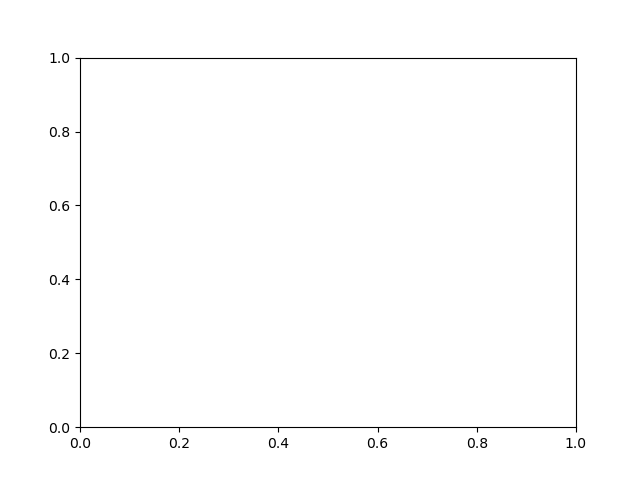

In [31]:
sum_sulfur = [(x + y)/2 for x,y in zip(y1, y5)]
sum_li2S = [(x + y + z)/3 for x,y,z in zip(y2,y3,y4)]

fig, ax1 = plt.subplots()

ax1.plot(x1, sum_sulfur, label = 'sulfur')
ax1.plot(x1, sum_li2S, label = 'Li2S')
ax2 = fig.add_axes(ax1.get_position(), frameon=False)
ax2.plot(Elec_Xdata,Elec_Ydata, 'g--')
ax2.xaxis.set_ticks_position('top')
ax2.yaxis.set_ticks_position('right')

ax1.legend()

In [54]:
ap = [1,2,3]
ao = [3,4,5]
ap += ao
print(ap)

[1, 2, 3, 3, 4, 5]
